In [1]:
import pandas as pd
import numpy as np

# Load Dataset

In [19]:
playlist = pd.read_csv("recommendations.csv")
playlist_original = pd.read_csv("/Users/ohungchan/Downloads/playlist_final_final.csv")
tracks = pd.read_csv("../phase5_model_development/dataset/tracks_new.csv")

### Temporary

In [20]:
import re

def parse_float64_list(val):
    if isinstance(val, str):
        # Extract all float-like numbers from inside np.float64(...)
        float_values = re.findall(r'np\.float64\(([\d\.]+)\)', val)
        return [int(float(v)) for v in float_values]
    elif isinstance(val, list):
        return [int(float(x)) for x in val]
    else:
        return []

playlist['recommended_tracks'] = playlist['recommended_tracks'].apply(parse_float64_list)


In [12]:
# def convert_string_array_to_list(s):
#     """Convert a string representation of an array into a list of integers."""
#     if isinstance(s, str):  # Handle string case (where it's incorrectly stored)
#         numbers = re.findall(r'\d+', s)  # Extract all numeric values
#         return [int(x) for x in numbers]  # Convert to integers
    
#     elif isinstance(s, np.ndarray):  # Handle NumPy array case
#         return s.astype(int).tolist()
    
#     elif isinstance(s, list):  # Handle lists with possible string numbers
#         return [int(x) for x in s if str(x).isdigit()]
    
#     return []  # Return empty list if the format is unexpected

# # Apply function and debug output
# playlist_original['tracks_to_predict'] = playlist_original['tracks_to_predict'].apply(lambda x: convert_string_array_to_list(x))

# # Check if the transformation worked
# print(playlist_original[['tracks_to_predict']].head(10))  # Print first 10 rows

### Merge playlist recommended

In [21]:
merged = playlist_original.merge(playlist, on='playlist_idx', how='inner')
merged = merged[['playlist_idx', 'cluster', 'tracks_to_predict', 'recommended_tracks']]

### Manipulation

In [22]:
tracks['track_popularity'] = tracks['track_popularity'] / 100
tracks['track_idx'] = tracks['track_idx'].astype(int)
tracks = tracks.set_index('track_idx')
playlist_original['popularity_mean'] = playlist_original['popularity_mean'] / 100
playlist_original['playlist_idx'] = playlist_original['playlist_idx'].astype(int)
playlist_original = playlist_original.set_index('playlist_idx')

In [23]:
tracks_relevant_columns = tracks[['track_popularity',
                                  'Early Years', 'Classic Era', 'Golden Era', '2000s', 'Modern Era',
                                  'Short', 'Medium', 'Long',
                                  "joy", "calm", "sadness", "fear", "energizing", "dreamy",
                                  "Instrumental / Ambient Sounds", "Soft Acoustic / Classical", "Orchestral / Soundtrack", "Mid-tempo Pop / Indie", "Upbeat Electronic / Dance", "Slow & Melancholic (Sad Songs)", "Experimental / Jazz Fusion", "Lo-Fi / Chill Vibes"]]

In [16]:
# playlist_original['sentiment_centroid'] = playlist_original['sentiment_centroid'].apply(lambda x: np.fromstring(x.strip("[]"), sep=" "))
# playlist_original['genre_centroid'] = playlist_original['genre_centroid'].apply(lambda x: np.fromstring(x.strip("[]"), sep=" "))

# # Unpack the column into separate columns
# playlist_original[['genre1', 'genre2', 'genre3', 'genre4', 'genre5', 'genre6', 'genre7', 'genre8']] = pd.DataFrame(playlist_original['genre_centroid'].tolist())

# # Drop the original column if you no longer need it
# playlist_original = playlist_original.drop(columns=['genre_centroid'])

# # Unpack the column into separate columns
# playlist_original[['sent1', 'sent2', 'sent3', 'sent4', 'sent5', 'sent6']] = pd.DataFrame(playlist_original['sentiment_centroid'].tolist())

# # Drop the original column if you no longer need it
# playlist_original = playlist_original.drop(columns=['sentiment_centroid'])

# print(playlist_original)

In [24]:
playlist_relevant_columns = playlist_original[['popularity_mean', 
                                      'era_early_years_proportion', 'era_classic_era_proportion', 'era_golden_era_proportion', 'era_2000s_proportion', 'era_modern_era_proportion',
                                      'length_short_proportion', 'length_medium_proportion', 'length_long_proportion',
                                      "sentiment_joy_centroid", "sentiment_calm_centroid", "sentiment_sadness_centroid", "sentiment_fear_centroid", "sentiment_energizing_centroid", "sentiment_dreamy_centroid",
                                      "genre_Instrumental / Ambient Sounds_centroid", "genre_Soft Acoustic / Classical_centroid", "genre_Orchestral / Soundtrack_centroid", "genre_Mid-tempo Pop / Indie_centroid", "genre_Upbeat Electronic / Dance_centroid", "genre_Slow & Melancholic (Sad Songs)_centroid", "genre_Experimental / Jazz Fusion_centroid", "genre_Lo-Fi / Chill Vibes_centroid"]]

KeyError: "['sentiment_joy_centroid', 'sentiment_calm_centroid', 'sentiment_sadness_centroid', 'sentiment_fear_centroid', 'sentiment_energizing_centroid', 'sentiment_dreamy_centroid'] not in index"

# Relevance

In [18]:
from sklearn.metrics.pairwise import cosine_similarity

def avg_cosine_similarity(set_a, set_b, tracks_df, track_feat_columns):
    """
    Computes the average cosine similarity between all track pairs (a, b)
    where a ∈ set_a and b ∈ set_b, based on the provided track feature columns.
    """
    # Convert set_a and set_b to list if they are not already
    set_a = list(set_a)
    set_b = list(set_b)
    
    # Make sure that the track indices are valid
    a_vectors = tracks_df.loc[set_a, track_feat_columns].values
    b_vectors = tracks_df.loc[set_b, track_feat_columns].values
    
    if a_vectors.shape[0] == 0 or b_vectors.shape[0] == 0:
        return 0.0  # Avoid similarity calculation if vectors are empty

    # Compute the cosine similarity between all pairs of tracks in a_vectors and b_vectors
    sim_matrix = cosine_similarity(a_vectors, b_vectors)
    return sim_matrix.mean()

# Example: To apply this on each playlist
def compute_relevance_for_playlist(row, tracks_df, track_feat_columns):
    true_tracks = row['tracks_to_predict']
    recommended_tracks = row['recommended_tracks']
    
    # Calculate cosine similarity for the top k recommended tracks and true tracks
    sim_score = avg_cosine_similarity(recommended_tracks, true_tracks, tracks_df, track_feat_columns)
    return sim_score

# Apply this to the dataset and create a new column in the `merged` DataFrame
merged['relevance'] = merged.apply(compute_relevance_for_playlist, axis=1, 
                                               tracks_df=tracks, track_feat_columns=tracks_relevant_columns.columns)

# Print the updated DataFrame
print(merged[['playlist_idx', 'relevance']].head())

KeyError: "None of [Index(['[', '2', '3', '2', '8', '4', '5', ',', ' ', '1', '1', '1', '8', '8',\n       '7', ',', ' ', '1', '4', '4', '1', '6', '0', ',', ' ', '1', '0', '6',\n       '6', '3', ',', ' ', '2', '1', '6', '3', '2', '1', ',', ' ', '1', '3',\n       '8', '8', '6', '9', ',', ' ', '6', '3', '6', '9', '4', ',', ' ', '7',\n       '2', '4', '3', '1', ',', ' ', '1', '0', '8', '7', '8', '2', ',', ' ',\n       '1', '7', '5', '6', '4', '2', ']'],\n      dtype='object', name='track_idx')] are in the [index]"

In [ ]:
# Group by the 'cluster' column and calculate the average cosine similarity for each cluster
cluster_avg_relevance = merged.groupby('cluster')['relevance'].mean()

# Print the average cosine similarity for each cluster
print(cluster_avg_relevance)

cluster
0    0.585748
1    0.543046
2    0.593087
3    0.395066
Name: relevance, dtype: float64


# Diversity

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def calculate_diversity_score(recommended_tracks, tracks_df, track_feat_columns):
    """
    Calculate the diversity score for a given set of recommended tracks.
    The diversity score is based on the average pairwise cosine similarity between recommended tracks.
    A lower cosine similarity indicates higher diversity.
    """
    # Extract the feature vectors of the recommended tracks
    recommended_vectors = tracks_df.loc[recommended_tracks, track_feat_columns].values
    
    if recommended_vectors.shape[0] == 0:
        return 0.0  # If there are no recommended tracks, return a default score
    
    # Compute the pairwise cosine similarity between all recommended tracks
    sim_matrix = cosine_similarity(recommended_vectors)
    
    # We remove the diagonal of the similarity matrix, as it represents self-similarity
    np.fill_diagonal(sim_matrix, 0)  # Set the diagonal to 0 to ignore self-similarity
    
    # Calculate the average of the off-diagonal similarities
    avg_similarity = sim_matrix.sum() / (sim_matrix.shape[0] * (sim_matrix.shape[0] - 1))
    
    # Diversity score: lower cosine similarity means higher diversity
    diversity_score = 1 - avg_similarity  # You can also directly return avg_similarity if you prefer
    
    return diversity_score

# Example: Apply this to each playlist
def compute_diversity_for_playlist(row, tracks_df, track_feat_columns):
    recommended_tracks = row['recommended_tracks']
    
    # Calculate the diversity score for the recommended tracks
    diversity_score = calculate_diversity_score(recommended_tracks, tracks_df, track_feat_columns)
    return diversity_score

# Apply this function to the merged DataFrame to get the diversity score for each playlist
merged['diversity'] = merged.apply(compute_diversity_for_playlist, axis=1, 
                                          tracks_df=tracks, track_feat_columns=tracks_relevant_columns.columns)

# Print the dataframe with the diversity scores
print(merged[['playlist_idx', 'diversity']].head())

   playlist_idx  diversity
0             2   0.321070
1             5   0.120568
2             6   0.276976
3            11   0.407393
4            17   0.182643


In [ ]:
# Group by the 'cluster' column and calculate the average cosine similarity for each cluster
cluster_avg_diversity = merged.groupby('cluster')['diversity'].mean()

# Print the average cosine similarity for each cluster
print(cluster_avg_diversity)

cluster
0    0.233069
1    0.322959
2    0.271909
3    0.370566
Name: diversity, dtype: float64


# Serendipity

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def compute_novelty(row, playlist_relevant_df, tracks_df, playlist_feat_columns, track_feat_columns):
    # Get playlist feature vector (assume index of row matches that in playlist_relevant_df)
    playlist_vector = playlist_relevant_df.loc[row.name, playlist_feat_columns].values.reshape(1, -1)

    # Get track IDs for recommended tracks
    recommended_ids = row['recommended_tracks']
    
    # Make sure it's a list of valid indices
    recommended_ids = list(recommended_ids)
    
    # Get feature vectors for recommended tracks
    track_vectors = tracks_df.loc[recommended_ids, track_feat_columns].values
    
    if track_vectors.shape[0] == 0:
        return 0.0  # Avoid errors on empty recommended lists
    
    # Compute cosine similarity between playlist and each recommended track
    sim_scores = cosine_similarity(playlist_vector, track_vectors)[0]  # Shape (n_tracks,)
    
    # Novelty = 1 - average similarity
    novelty_score = 1 - np.mean(sim_scores)
    return novelty_score


# Align indices
merged = merged.reset_index(drop=True)
playlist_original = playlist_original.reset_index(drop=True)

merged['novelty'] = merged.apply(
    compute_novelty,
    axis=1,
    playlist_relevant_df=playlist_original,
    tracks_df=tracks,
    playlist_feat_columns=playlist_relevant_columns.columns,
    track_feat_columns=tracks_relevant_columns.columns
)

merged['serendipity'] = merged['relevance'] * merged['novelty']

print(merged[['playlist_idx', 'serendipity']].head())

   playlist_idx  serendipity
0             2     0.232496
1             5     0.284754
2             6     0.300612
3            11     0.231462
4            17     0.150423


In [ ]:
# Group by the 'cluster' column and calculate the average cosine similarity for each cluster
cluster_avg_serendipity = merged.groupby('cluster')['serendipity'].mean()

# Print the average cosine similarity for each cluster
print(cluster_avg_serendipity)

cluster
0    0.217528
1    0.190647
2    0.218653
3    0.211786
Name: serendipity, dtype: float64


# Visualization

In [ ]:
playlist_scores = merged[['playlist_idx', 'cluster', 'relevance', 'diversity', 'serendipity']]

,playlist_idx,cluster,relevance,diversity,serendipity
0,2,3,0.411353,0.321070,0.232496
1,5,0,0.550780,0.120568,0.284754
2,6,1,0.538711,0.276976,0.300612
3,11,3,0.423497,0.407393,0.231462
4,17,2,0.415050,0.182643,0.150423
...,...,...,...,...,...
195,1049,1,0.412316,0.328465,0.160177
196,1051,1,0.550433,0.479383,0.272786
197,1054,3,0.458429,0.523743,0.268481
198,1058,0,0.661820,0.213235,0.164790


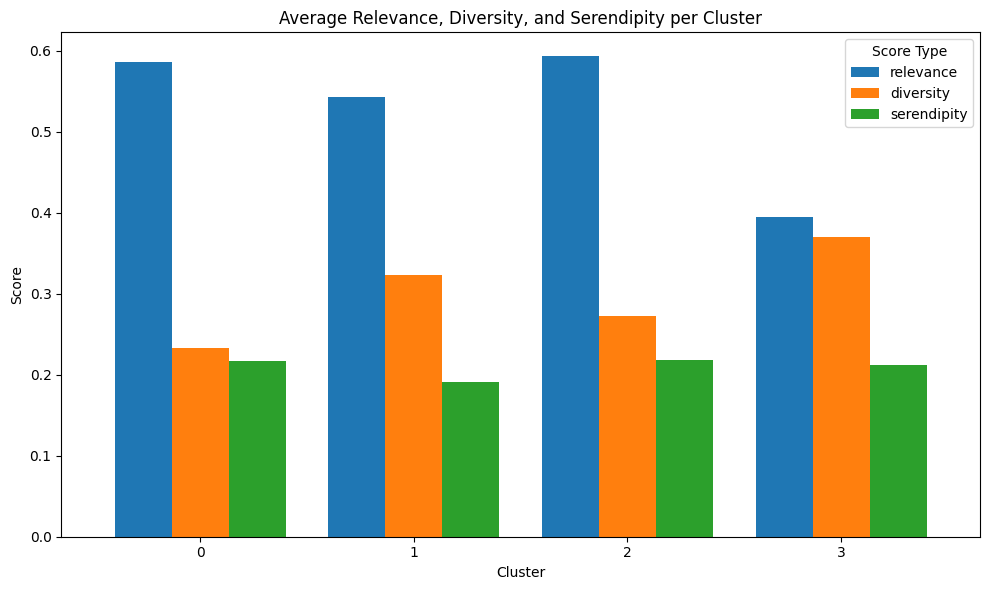

In [ ]:
import matplotlib.pyplot as plt

# Step 1: Group by cluster and take the mean of each score
cluster_means = playlist_scores.groupby('cluster')[['relevance', 'diversity', 'serendipity']].mean()

# Step 2: Plot grouped bar chart
cluster_means.plot(kind='bar', figsize=(10, 6), width=0.8)

plt.title('Average Relevance, Diversity, and Serendipity per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(title='Score Type')
plt.tight_layout()
plt.show()

# Analysis

In [ ]:
from scipy.stats import f_oneway

# Prepare a function to conduct ANOVA for a given score
def perform_anova(df, score_col, group_col='cluster'):
    # Group the score values by cluster
    grouped_scores = [group[score_col].values for name, group in df.groupby(group_col)]
    # Perform one-way ANOVA
    f_stat, p_val = f_oneway(*grouped_scores)
    return f_stat, p_val

# Run ANOVA for each score
for score in ['relevance', 'diversity', 'serendipity']:
    f_stat, p_val = perform_anova(playlist_scores, score)
    print(f"ANOVA for {score}: F = {f_stat:.4f}, p = {p_val:.4e}")

ANOVA for relevance: F = 49.9540, p = 5.0070e-24
ANOVA for diversity: F = 15.6545, p = 3.6289e-09
ANOVA for serendipity: F = 2.5816, p = 5.4677e-02


In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd

# Function to perform Tukey's HSD test for a given score
def tukey_posthoc(df, score_col, group_col='cluster'):
    tukey = pairwise_tukeyhsd(endog=df[score_col],
                              groups=df[group_col],
                              alpha=0.05)
    print(f"\nTukey HSD results for {score_col}:\n")
    print(tukey.summary())

# Run Tukey HSD for each score
for score in ['relevance', 'diversity', 'serendipity']:
    tukey_posthoc(playlist_scores, score)


Tukey HSD results for relevance:

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     0      1  -0.0427 0.1388  -0.094  0.0086  False
     0      2   0.0073 0.9836 -0.0451  0.0597  False
     0      3  -0.1907    0.0 -0.2447 -0.1366   True
     1      2     0.05 0.0127  0.0079  0.0922   True
     1      3   -0.148    0.0 -0.1922 -0.1038   True
     2      3   -0.198    0.0 -0.2435 -0.1525   True
----------------------------------------------------

Tukey HSD results for diversity:

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     0      1   0.0899 0.0002  0.0342  0.1455   True
     0      2   0.0388  0.291  -0.018  0.0957  False
     0      3   0.1375    0.0  0.0788  0.1962   True
     1      2   -0.051  0.022 -0.0968 -0.0053   True
     1      3   0.0476 0.0527